In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
#Loading dataset
df = pd.read_csv("/content/ifood_df.csv")
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df[['Income', 'MntTotal', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'Recency']].describe()

,Income,MntTotal,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Recency
count,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000
mean,51687.258783,563.789213,4.115289,2.644730,5.807521,48.880752
std,20713.046401,576.775749,2.753588,2.799126,3.230434,28.950917
min,1730.000000,4.000000,0.000000,0.000000,0.000000,0.000000
25%,35416.000000,55.000000,2.000000,0.000000,3.000000,24.000000
50%,51412.000000,343.000000,4.000000,2.000000,5.000000,49.000000
75%,68274.000000,964.000000,6.000000,4.000000,8.000000,74.000000
max,113734.000000,2491.000000,27.000000,28.000000,13.000000,99.000000


In [ ]:
Mean = df['MntTotal'].mean()
print("Average Spending: ", Mean)

df['TotalPurchases'] = (
    df['NumWebPurchases']
    + df['NumCatalogPurchases']
    + df['NumStorePurchases']
)

print("Average Purchase Frequency:",
      df['TotalPurchases'].mean())

Average Spending:  563.789213260762
Average Purchase Frequency: 12.567540821375557


In [ ]:
X = df[['Income', 'MntTotal', 'TotalPurchases', 'Recency']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

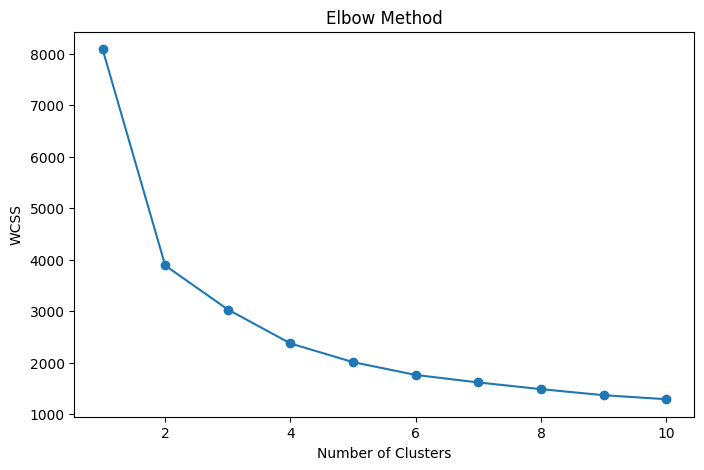

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

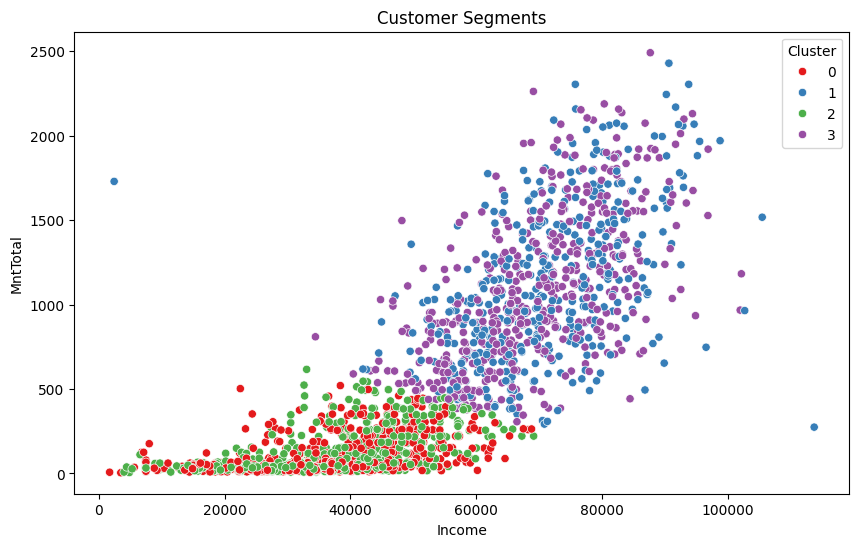

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='MntTotal',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

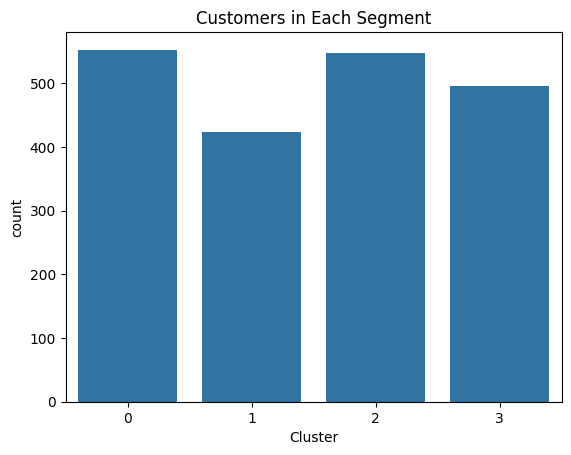

In [ ]:
sns.countplot(
    data=df,
    x='Cluster'
)

plt.title("Customers in Each Segment")
plt.show()

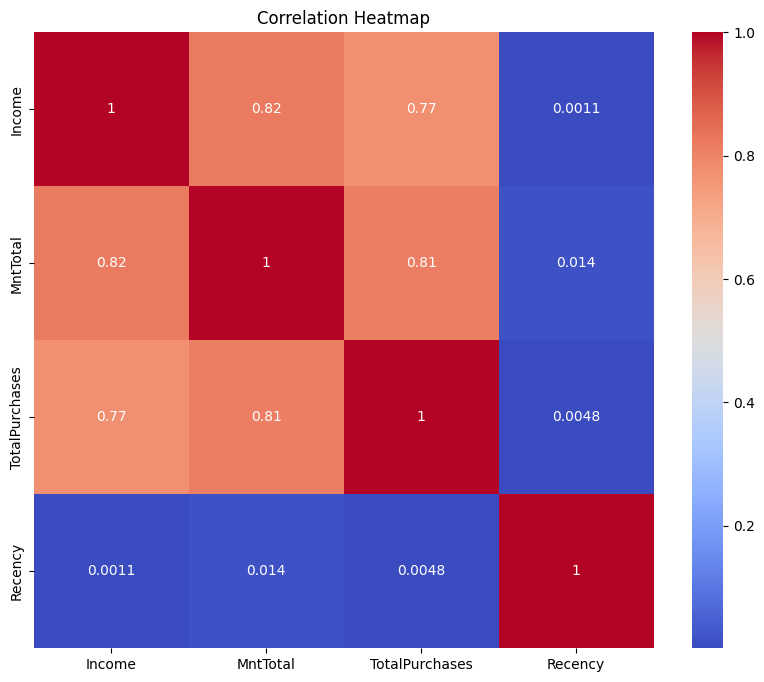

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[['Income',
        'MntTotal',
        'TotalPurchases',
        'Recency']]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
segment_summary = df.groupby('Cluster')[
    ['Income',
     'MntTotal',
     'TotalPurchases',
     'Recency']
].mean()

print(segment_summary)

               Income     MntTotal  TotalPurchases    Recency
Cluster                                                      
0        36248.817360   115.815552        6.831826  73.077758
1        71136.757075  1120.077830       19.582547  22.764151
2        36515.197080   129.870438        7.187956  23.016423
3        69036.372984  1067.116935       18.909274  72.804435


In [ ]:
""" Recommendations

Segment 0 – High Value Customers
- Offer loyalty rewards and exclusive discounts.
- Provide premium customer support.

Segment 1 – Low Engagement Customers
- Use promotional campaigns to encourage purchases.
- Send personalized recommendations.

Segment 2 – Regular Customers
- Introduce membership programs.
- Upsell complementary products.

Segment 3 – Frequent Buyers
- Offer subscription plans and bundle deals.
- Encourage larger purchases through discounts."""

' Recommendations\n\nSegment 0 – High Value Customers\n- Offer loyalty rewards and exclusive discounts.\n- Provide premium customer support.\n\nSegment 1 – Low Engagement Customers\n- Use promotional campaigns to encourage purchases.\n- Send personalized recommendations.\n\nSegment 2 – Regular Customers\n- Introduce membership programs.\n- Upsell complementary products.\n\nSegment 3 – Frequent Buyers\n- Offer subscription plans and bundle deals.\n- Encourage larger purchases through discounts.'